# AIC, BIC, LR test

Once you have fitted a model with [SVGD](svgd-basics.ipynb), you typically want to know whether your model is *the right shape* for the data. Phasic provides three classical recipes built directly on top of a fitted `SVGD` object:

- **AIC** ($2k - 2\,\log\hat L$) for ranking models on a parsimony/fit tradeoff.
- **BIC** ($k \log n - 2\,\log\hat L$) for a more aggressive penalty on complexity.
- **Likelihood-ratio test** for two nested models, where one fixes some parameters that the other estimates freely.

All three rest on the same three quantities exposed on every fitted `SVGD` instance:

- `svgd.log_likelihood()` — the maximum log-likelihood $\log \hat L = \sum_i \log p(x_i \mid \hat\theta)$ at the MAP.
- `svgd.degrees_of_freedom` — the number $k$ of free parameters (`theta_dim` minus the number fixed via `fixed=`).
- `svgd.n_observations` — the effective sample size $n$ (number of non-NaN entries for dense data, or `len(values)` for `SparseObservations`).

In [ ]:
import phasic
from phasic import (
    Graph, with_ipv, SVGD, GaussPrior, ExpStepSize, Adamelia,
    clear_caches, set_log_level, StateIndexer, Property,
    model_selection, 
)
phasic.configure(parallel_elimination=True, reward_compute_cache=True)

from itertools import combinations_with_replacement
from functools import partial
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)

from vscodenb import set_vscode_theme
set_vscode_theme()


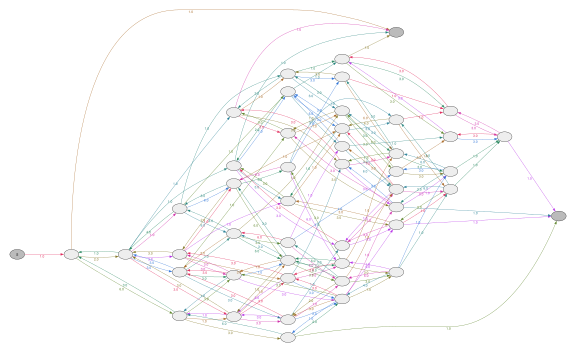

In [ ]:
def two_locus_ghost_island(state, indexer=None):

    coef_len = 6

    pop1_coal_idx = 0
    pop1_rec_idx = 1
    pop1_mig_idx = 2
    pop2_coal_idx = 3
    pop2_rec_idx = 4
    pop2_mig_idx = 5

    transitions = []

    nonzero_idx = np.nonzero(state[:indexer.descendants.state_length])[0]
    
    if state.sum() <= 1: return transitions
    
    for i, j in all_pairs(nonzero_idx):

    # for i in range(indexer.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        
        # for j in range(i, indexer.state_length):
        if state[j] == 0: continue
        props_j = indexer.descendants.index_to_props(j)

        if props_j.in_pop != props_i.in_pop:
            # skip if in different pops            
            continue

        same = int(i == j)
        if same and state[i] < 2:
            # skip if same and less than two lineages
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            # skip if different and either kind has no lineages
            continue 

        # coalescence
        loc1=props_i.loc1 + props_j.loc1
        loc2=props_i.loc2 + props_j.loc2
        if loc1 <= nr_samples and loc2 <= nr_samples:
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            k = indexer.descendants.props_to_index(
                loc1=props_i.loc1 + props_j.loc1,
                loc2=props_i.loc2 + props_j.loc2,
                in_pop=props_i.in_pop
                )
            child[k] += 1
            # validate(child, indexer, state)

            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 1:
                coef[pop1_coal_idx] = state[i]*(state[j]-same)/(1+same)
            else:
                coef[pop2_coal_idx] = state[i]*(state[j]-same)/(1+same)
            transitions.append([child, coef])

            # transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0, 0]])

    for i in nonzero_idx:
        props_i = indexer.descendants.index_to_props(i)
        
        # recombination
        loc1 = props_i.loc1 
        loc2 = props_i.loc2
        if state[i] > 0 and 0 < loc1 <= nr_samples and 0 < loc2 <= nr_samples:
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                loc1=0,
                loc2=props_i.loc2, 
                in_pop=props_i.in_pop
                )
            child[k] += 1
            k = indexer.descendants.props_to_index(
                loc1=props_i.loc1,
                loc2=0, 
                in_pop=props_i.in_pop
                )
            child[k] += 1
            # validate(child, indexer, state)
            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 1:
                coef[pop1_rec_idx] = state[i]
            else:
                coef[pop2_rec_idx] = state[i]
            transitions.append([child, coef])            
#            transitions.append([child, [0, state[i], 0]])

        # migration
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                loc1=props_i.loc1,
                loc2=props_i.loc2, 
                in_pop=other_pop
                )
            child[k] += 1
            # validate(child, indexer, state)
            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 2:
                 coef[pop1_mig_idx] = state[i]
            else:
                coef[pop2_mig_idx] = state[i]
            transitions.append([child, coef])                      
            # transitions.append([child, [0, 0, state[i]]])

    return transitions

nr_samples = 2
true_theta = [
    # pop1_coal, pop1_rec, pop1_mig, 
    1, 1, 3,  
    # pop2_coal, pop2_rec, pop2_mig
    1, 1, 3, 
]
mutation_rate = 0.1
reward_limit = 1

indexer = StateIndexer(
    descendants=[        
        Property('loc1', min_value=0, max_value=nr_samples),
        Property('loc2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ],
)
indexer.state_length
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(loc1=1, loc2=1, in_pop=1)] = nr_samples

graph = Graph(two_locus_ghost_island, ipv=initial, indexer=indexer)   
graph.update_weights(true_theta)

graph.plot(nodesep=0.4, ranksep=2, max_nodes=200, 
           label_fmt=False, size=(8,8),
           )

In [ ]:
jp_graph = graph.joint_prob_graph(reward_limit=reward_limit, 
                                  mutation_rate=mutation_rate)
jp_graph.vertices_length()

5380

In [4]:
jp_graph.update_weights(true_theta + [mutation_rate])
joint_prob_table = jp_graph.joint_prob_table()
(1 - joint_prob_table['prob'].sum()).item()

0.008802869841632588

In [5]:
def sample_joint_observations(joint_prob_graph, theta, nr_observations):
    joint_prob_graph.update_weights(theta) 
    joint_prob_table = joint_prob_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

observations = sample_joint_observations(jp_graph, true_theta + [mutation_rate], nr_observations=1000)
observations[:5]

[[0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0]]

In [6]:
jp_graph = graph.joint_prob_graph(reward_limit=reward_limit, 
                                   mutation_rate=mutation_rate)                                        

In [7]:
%%monitor
svgd = jp_graph.svgd(
    observations, 
    preconditioner='none',
    prior=GaussPrior(ci=[0.1, 7]),
    n_iterations=50,
    n_particles=50,
    optimizer=Adamelia(learning_rate=0.2),
    fixed=[(3, mutation_rate)], 
    progress=True,
    )
svgd.summary()  

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             5.683      2.381      1.96       0.1737       6.086       
1          No             2.942      3.54       1.062      1.673        5.237       
2          No             0.9952     1.705      0.804      0.6831       3.392       
3          Yes            0.1        NA         NA         NA           NA          
4          No             0.187      1.01       0.6587     0.02215      2.087       
5          No             3.843      6.924      1.797      3.843        9.391       
6          No             0.082      1.778      0.9772     0.005796     2.894       

Particles: 50, Iterations: 50


In [8]:
# print(f"log L̂ = {svgd.log_likelihood(refine=True):.4f}")
print(f"log L̂ = {svgd.log_likelihood(refine=False):.4f}")
print(f"k (free params) = {svgd.degrees_of_freedom}")
print(f"n (obs) = {svgd.n_observations}")

log L̂ = -1556.5178
k (free params) = 6
n (obs) = 1000


## AIC and BIC for a single fit

`refine=True` runs a short gradient-ascent refinement of the MAP particle on the log-posterior before evaluating the log-likelihood. The result is closer to the MLE under weak priors and gives a sharper AIC/BIC.

In [9]:
# print(model_selection.aic(svgd, refine=True))
# print(model_selection.bic(svgd, refine=True))
print(model_selection.aic(svgd, refine=False))
print(model_selection.bic(svgd, refine=False))

AICResult(aic=3125.0357, log_likelihood=-1556.5178, k=6, n=1000, refined=False)
BICResult(bic=3154.4822, log_likelihood=-1556.5178, k=6, n=1000, refined=False)


## Model comparison

Same model but fitting separate coalescence rates for each epoch. If you want to compare models using AIC or BIC, you can fit this model just like the one above. However, to allow an LR test of nested models, you must make the fits on the *same model* only changing the `fixed` or `tied` kwargs. You can extract and reuse the model like this:

In [ ]:
svgd_no_mig = SVGD(
    model=svgd.model,
    theta_dim=svgd.theta_dim,
    # Reuse the *processed* observations from the first fit — for a joint-prob
    # model these are the per-observation positions, not the raw 2D array.
    observed_data=svgd.observed_data,
    preconditioner='none',
    prior=GaussPrior(ci=[0.1, 7]),
    n_iterations=50,
    n_particles=50,
    optimizer=Adamelia(learning_rate=0.2),
    fixed=[(1, 0), (3, mutation_rate)], 
    progress=True,
)
svgd_no_mig.optimize()
svgd_no_mig.summary()

In [ ]:
# print(f"log L̂ = {svgd_all_coal_free.log_likelihood(refine=True):.4f}")
print(f"log L̂ = {svgd_no_mig.log_likelihood(refine=False):.4f}")
print(f"k (free params) = {svgd_no_mig.degrees_of_freedom}")
print(f"n (obs) = {svgd_no_mig.n_observations}")

In [ ]:
# print(model_selection.aic(svgd_no_mig, refine=True))
# print(model_selection.bic(svgd_no_mig, refine=True))
print(model_selection.aic(svgd_no_mig, refine=False))
print(model_selection.bic(svgd_no_mig, refine=False))

Compare the two models:

In [ ]:
table = model_selection.compare(
    ("with-migration", svgd),
    ("no-migration", svgd_no_mig),
    criterion='aic',
    # refine=True,
    refine=False,
)
print(table)

Reading the table:

- Rows are sorted ascending by AIC — the best model is on top.
- `Δ` is the AIC difference from the best model. Rules of thumb (Burnham & Anderson): Δ < 2 means "essentially equivalent", 4–7 means "considerably less support", > 10 means "essentially no support".
- `weight` is the Akaike weight $\exp(-\Delta_i / 2) / \sum_j \exp(-\Delta_j / 2)$ — the probability, under the AIC/Kullback–Leibler approximation, that model $i$ is the best of the set.

The one-rate model wins AIC even though the data were generated from the two-rate model. With Δ ≈ 1.6 between the two, the data are *not* strong enough to justify the extra parameter — AIC is doing exactly the job it should. The three-rate model is meaningfully worse (Δ ≈ 3.6), which is reassuring: the spurious extra parameter is being penalized.

Switch to BIC for a more aggressive complexity penalty:

In [ ]:
print(model_selection.compare(
    ("with-migration", svgd),
    ("no-migration", svgd_no_mig),
    criterion='bic',
    # refine=True,
    refine=False,
))

## Likelihood-ratio test for nested models

Information criteria rank models that may or may not be nested. When you have a **truly nested** restriction (the nested model fixes some parameters of the full model at specific values), the likelihood-ratio test gives a frequentist p-value under the null hypothesis that the restriction holds:

$$
2 \bigl( \log \hat L_\mathrm{full} - \log \hat L_\mathrm{nested} \bigr) \;\sim\; \chi^2_{\,k_\mathrm{full} - k_\mathrm{nested}}
$$

Phasic enforces strict nesting: both fits must use the **same** model callable (the closure returned by one call to `Graph.pmf_and_moments_from_graph`), the same `theta_dim`, the same number of observations, and the nested fit's `fixed` set must be a strict superset of the full fit's `fixed` set. That's exactly the relationship between `svgd` (migration free, `fixed=[(3, mutation_rate)]`) and `svgd_no_mig` (migration fixed to zero, `fixed=[(1, 0), (3, mutation_rate)]`):

In [ ]:
# Full = svgd (migration free); nested = svgd_no_mig (migration fixed to 0).
# svgd_no_mig's fixed set is a strict superset of svgd's, so they're nested.
lrt = model_selection.likelihood_ratio_test(svgd, svgd_no_mig)
print(lrt)

If the p-value is small (the conventional cutoff is 0.05), the data reject the one-rate restriction — the full two-rate model fits significantly better. A large p-value means the restriction is consistent with the data and the simpler one-rate model can be retained.

In our example p ≈ 0.51 — the test fails to reject the one-rate restriction, in agreement with the AIC/BIC ranking. This is the typical outcome when the two rates are *similar* relative to the sample size: the likelihood under the two-rate fit is barely better than under the one-rate fit, the statistic 2·(LL_full − LL_nested) is small, and χ²₁ assigns it a large p-value.

::: { .callout-warning }

**Strict nesting is enforced.** If you try to LRT two fits that were built from separate `Graph.pmf_and_moments_from_graph` calls — even on the same underlying graph — `likelihood_ratio_test` raises a `ValueError`. The rule of thumb: build the model callable once, then pass it to every `SVGD` you intend to compare.

If you want to compare two models that aren't strictly nested (e.g. different graphs entirely), use `compare()` with AIC or BIC instead — these don't require nesting, only the same data.

:::

## Continuous time epoch models

In [ ]:
cjp_graph = graph.joint_prob_graph(reward_limit=reward_limit, 
                                          mutation_rate=mutation_rate,
                                          discrete=False) # <-- NB!                                          

In [ ]:
set_log_level('DEBUG')

In [ ]:
%%monitor
svgd_all_tied = cjp_graph.svgd(
    observations, 
    preconditioner='none',
    prior=GaussPrior(ci=[0.1, 7]),
    # n_iterations=20,
    # n_particles=20,
    n_iterations=100,
    n_particles=50,
    optimizer=Adamelia(learning_rate=0.2),
    fixed=[(3, mutation_rate)], 
    epoch_starts=[0, 0.5],
    tied=[
        (0, [0, 1]), # tie coal rate in epoch 0 and 1
        (1, [0, 1]), # tie rec  rate in epoch 0 and 1
        (2, [0, 1]), # tie mig  rate in epoch 0 and 1. 
    ],
    daisy_chain_t_eval='auto',
#    daisy_chain_granularity=50,
    progress=True,
    )
svgd_all_tied.summary()    

In [ ]:
# print(f"log L̂ = {svgd_all_tied.log_likelihood(refine=True):.4f}")
print(f"log L̂ = {svgd_all_tied.log_likelihood(refine=False):.4f}")
print(f"k (free params) = {svgd_all_tied.degrees_of_freedom}")
print(f"n (obs) = {svgd_all_tied.n_observations}")

In [ ]:
# print(model_selection.aic(svgd_all_tied, refine=True))
# print(model_selection.bic(svgd_all_tied, refine=True))
print(model_selection.aic(svgd_all_tied, refine=False))
print(model_selection.bic(svgd_all_tied, refine=False))

Same model but fitting separate coalescence rates for each epoch. If you want to compare models using AIC or BIC, you can fit this model just like the one above. However, to allow an LR test of nested models, you must make the fits on the *same model* only changing the `fixed` or `tied` kwargs. You can extract and reuse the model like this:

In [ ]:
%%monitor

svgd_all_coal_free = SVGD(
    model=svgd_all_tied.model,
    # Reuse the processed observations from the tied fit (not the raw array).
    observed_data=svgd_all_tied.observed_data, 
    preconditioner=None,
    prior=GaussPrior(ci=[0.1, 7]),
    # n_iterations=20,
    # n_particles=20,
    n_iterations=2,
    n_particles=5,
    optimizer=Adamelia(learning_rate=0.2),
    epoch_starts=[0, 0.5],
    tied=[
        # (0, [0, 1]), # tie coal rate in epoch 0 and 1  <--- Commented out to fit a coal rate per epoch
        (1, [0, 1]), # tie rec  rate in epoch 0 and 1
        (2, [0, 1]), # tie mig  rate in epoch 0 and 1.
    ],
    fixed=[(3, mutation_rate)], 
    progress=True,
)
svgd_all_coal_free.optimize()
svgd_all_coal_free.summary()

In [ ]:
# print(f"log L̂ = {svgd_all_coal_free.log_likelihood(refine=True):.4f}")
print(f"log L̂ = {svgd_all_coal_free.log_likelihood(refine=False):.4f}")
print(f"k (free params) = {svgd_all_coal_free.degrees_of_freedom}")
print(f"n (obs) = {svgd_all_coal_free.n_observations}")

In [ ]:
# print(model_selection.aic(svgd_all_coal_free, refine=True))
# print(model_selection.bic(svgd_all_coal_free, refine=True))
print(model_selection.aic(svgd_all_coal_free, refine=False))
print(model_selection.bic(svgd_all_coal_free, refine=False))

In [ ]:
table = model_selection.compare(
    ("separate-coal-rate-per-epoch", svgd_all_coal_free),
    ("all-params-tied-across-epochs", svgd_all_tied),
    criterion='aic',
    # refine=True,
    refine=False,
)
print(table)

In [ ]:
print(model_selection.compare(
    ("separate-coal-rate-per-epoch", svgd_all_coal_free),
    ("all-params-tied-across-epochs", svgd_all_tied),
    criterion='bic',
    # refine=True,
    refine=False,
))

In [ ]:
lrt = model_selection.likelihood_ratio_test(svgd_all_coal_free, svgd_all_tied)
print(lrt)